In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

In [65]:
df = pd.read_csv("IMDB Dataset.csv")
df.head(10)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive
6,I sure would like to see a resurrection of a u...,positive
7,"This show was an amazing, fresh & innovative i...",negative
8,Encouraged by the positive comments about this...,negative
9,If you like original gut wrenching laughter yo...,positive


In [66]:
encoder = LabelEncoder()
df['sentiment'] = encoder.fit_transform(df['sentiment'])
df['sentiment']

0        1
1        1
2        1
3        0
4        1
        ..
49995    1
49996    0
49997    0
49998    0
49999    0
Name: sentiment, Length: 50000, dtype: int32

In [67]:
X = df['review']
y = df['sentiment']

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [69]:
from tensorflow.keras.preprocessing.text import Tokenizer

#Keep only 100000 most frequent words
tokenizer = Tokenizer(num_words=10000)

#Learn from words
tokenizer.fit_on_texts(X_train)

#Convert words into numbers - By mapping to index to each word. eg. id 1 to most freq word, then id 2 to second most freq word,..
#Create vector of sequences for each word
X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)

In [70]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

#To keep all sequences of equal length - Add 0's if less than set size else remove exceeding elements than size 
maxLen = 200
X_train = pad_sequences(X_train, maxLen)
X_test = pad_sequences(X_test, maxLen)

In [71]:
#Build NN Model

model = Sequential()

#Embedding Layer - Convert numbers into verctor format, helps model to understand semantic relationship
model.add(Embedding(input_dim=10000, output_dim=32,input_length=maxLen))

#Flatten Layer
model.add(Flatten())

model.add(Dense(128, input_shape=(maxLen,), activation='relu', name='dense1'))

model.add(Dense(64, activation='relu', name='dense2'))

model.add(Dense(1, activation='sigmoid', name='output_dense'))

C:\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
C:\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [72]:
#Compile Model
#adam - Adaptive Movement Estimation -> Instead of updating weights with a fixed step size, Adam: adapts learning rate automatically
# remembers past gradients
# smooths updates - faster convergence
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (Dense)            │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [73]:
#Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.8152 - loss: 0.3842 - val_accuracy: 0.8769 - val_loss: 0.3013
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.9569 - loss: 0.1191 - val_accuracy: 0.8599 - val_loss: 0.3772
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.9895 - loss: 0.0292 - val_accuracy: 0.8606 - val_loss: 0.5448
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.9940 - loss: 0.0170 - val_accuracy: 0.8546 - val_loss: 0.6849
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.9952 - loss: 0.0133 - val_accuracy: 0.8512 - val_loss: 0.8735
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.9961 - loss: 0.0119 - val_accuracy: 0.8571 - val_loss: 0.8830
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.9967 - loss: 0.0110 - val_accuracy: 0.8530 - val_loss: 0.8565
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.9965 -

In [74]:
#Prediction 
y_pred = model.predict(X_test)

for i in range (1,10):
    print("Actual:", "Positive" if y_test.iloc[i] == 1 else "Negative")
    if(y_pred[i][0] > 0.5):
        print("Predicted: Positive")
    else:
        print("Predicted: Negative")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Actual: Positive
Predicted: Negative
Actual: Negative
Predicted: Negative
Actual: Positive
Predicted: Positive
Actual: Negative
Predicted: Negative
Actual: Positive
Predicted: Positive
Actual: Positive
Predicted: Positive
Actual: Positive
Predicted: Negative
Actual: Negative
Predicted: Positive
Actual: Negative
Predicted: Negative


In [75]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Loss: ", loss)
print("Accuracy: ", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8595 - loss: 0.9039
Loss:  0.9039251208305359
Accuracy:  0.859499990940094


<Axes: >

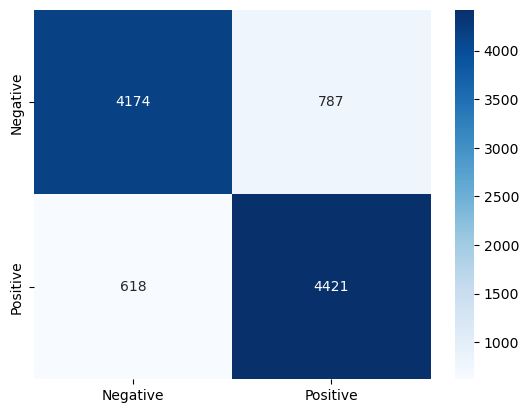

In [76]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred = (y_pred > 0.5)
cm = confusion_matrix(y_test, y_pred)
cm

sns.heatmap(cm, annot=True, cmap='Blues',fmt='d', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])

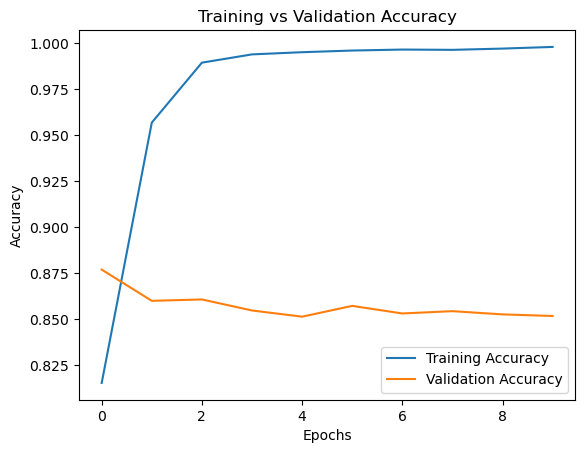

In [78]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.title('Training vs Validation Accuracy')

plt.legend()
plt.show()